### **Notebook 02** : Logistic Regression — Model Training & Experimentation
### **Input**  : X_train/test, y_train/test (from Notebook 01), scaler.pkl
### **Output** : lr_model.pkl, experiment results table

---
### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.titlesize'] = 13

print('Imports successful')

Imports successful


### Load data

In [2]:
# Data paths
DATA_DIR      = '../outputs/csv/'
OUT_DIR       = '../outputs/'


X_train = pd.read_csv(DATA_DIR + 'X_train.csv')
X_test = pd.read_csv(DATA_DIR + 'X_test.csv')
y_train = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()
y_test = pd.read_csv(DATA_DIR + 'y_test.csv').squeeze()

print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')
print(f'Class balance (train) — 0: {(y_train==0).sum()}  1: {(y_train==1).sum()} ({y_train.mean():.1%} positive)')
X_train.head()

X_train : (2883, 6)   X_test : (721, 6)
Class balance (train) — 0: 1416  1: 1467 (50.9% positive)


,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,PurchaseSpanDays
0,140,2,662.08,331.040000,17,70
1,53,4,2411.82,602.955000,195,154
2,8,3,534.12,178.040000,35,245
3,112,1,308.68,308.680000,18,0
4,9,3,469.00,156.333333,57,197


In [3]:
print(list(X_train.columns))

['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'PurchaseSpanDays']


### Feature transformation - Transform existing features to improve model performance

Base features were extracted from raw UCI Online Retail transactional data 
as per-customer behavioural summaries.Additional features are constructed via feature transformation to improve 
model performance:
- Log transforms: reduce skewness in tailed distributions
- Ratio features: capture relationships between existing features

In [4]:
def add_engineered_features(df):
    df = df.copy()

    # Log transforms (reduce skew for LR) 
    df['LogRecency'] = np.log1p(df['Recency'])
    df['LogMonetary'] = np.log1p(df['Monetary'])
    df['LogFrequency'] = np.log1p(df['Frequency'])

    # Ratio features 
    df['FreqPerSpanDay'] = df['Frequency'] / (df['PurchaseSpanDays'] + 1)   # avoid div/0
    df['MonetaryPerFreq'] = df['Monetary']  / (df['Frequency'] + 1)

    # Recency bucket (ordinal 0–4, lower = more recent) 
    df['RecencyBucket'] = pd.cut(df['Recency'], bins=5, labels=False)

    return df

# include new feature into the X_train and X_test dataframes
X_train = add_engineered_features(X_train)
X_test  = add_engineered_features(X_test)

print('Engineered features added. Available columns:')
print(list(X_train.columns))
print(X_train.shape, X_test.shape)

Engineered features added. Available columns:
['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'PurchaseSpanDays', 'LogRecency', 'LogMonetary', 'LogFrequency', 'FreqPerSpanDay', 'MonetaryPerFreq', 'RecencyBucket']
(2883, 12) (721, 12)


### Experiment Configurations

This section defines the central configuration for the experiment. The settings below control feature selection, data scaling, and model hyperparameters.

* FEATURE_COLS: selects which features are used for training
* SCALER_TYPE: defines the scaling method (standard, minmax, or robust)
* MODEL_PARAMS: sets logistic regression hyperparameters (C, penalty, solver)


In [5]:
# Feature selections for the training
FEATURE_COLS = [
    'Recency',  # days since last purchase
    'Frequency',  # number of orders
    'Monetary',  # total spend
    'AvgOrderValue',  # average order size
    'UniqueProducts',  # variety of items bought
    'PurchaseSpanDays',  # days between first and last purchase
    'LogRecency',
    'LogMonetary',
    'LogFrequency', 
    'FreqPerSpanDay',
    'RecencyBucket'
]

# standard, minmax, robust
SCALER_TYPE = "minmax"

# Model trianing hyperparameters
MODEL_PARAMS  = dict(
    C = 0.1,
    penalty = 'l2',      # l1, l2, None
    solver = 'saga',   # lbfgs, saga, liblinear
    max_iter = 2000,
    random_state = 42,
)

print('Config loaded.')
print(f'  Features      : {FEATURE_COLS}')
print(f'  Scaling       : {SCALER_TYPE}')
print(f'  C / penalty   : {MODEL_PARAMS["C"]} / {MODEL_PARAMS["penalty"]}')

Config loaded.
  Features      : ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'PurchaseSpanDays', 'LogRecency', 'LogMonetary', 'LogFrequency', 'FreqPerSpanDay', 'RecencyBucket']
  Scaling       : minmax
  C / penalty   : 0.1 / l2


### Prepare Data for Training

Validates that all configured features exist in the dataset before training.
Selected features are extracted from the train/test splits and scaled using
the normalisation method defined in SCALER_TYPE (standard, minmax, robust).
The scaler is fit on training data only and applied to the test set to
prevent data leakage.

In [6]:
# check features are available
missing_cols = [c for c in FEATURE_COLS if c not in X_train.columns]
if missing_cols:
    raise ValueError(f'These features are not in the dataset: {missing_cols}\n'
                     f'Run Section 4 first, or check for typos in FEATURE_COLS.')

Xtr = X_train[FEATURE_COLS].copy()
Xte = X_test[FEATURE_COLS].copy()

# scaling
if SCALER_TYPE:
    scalers = {
        'standard': StandardScaler(),
        'minmax': MinMaxScaler(),
        'robust': RobustScaler(),
    }
    scaler = scalers[SCALER_TYPE]
    Xtr = pd.DataFrame(scaler.fit_transform(Xtr), columns=FEATURE_COLS)
    Xte = pd.DataFrame(scaler.transform(Xte), columns=FEATURE_COLS)
    print(f'Scaling applied: {SCALER_TYPE}')
else:
    print('No scaling applied.')


print(f'\nFinal training shape : {Xtr.shape}')
print(f'Features used: {FEATURE_COLS}')

Scaling applied: minmax

Final training shape : (2883, 11)
Features used: ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'PurchaseSpanDays', 'LogRecency', 'LogMonetary', 'LogFrequency', 'FreqPerSpanDay', 'RecencyBucket']


### Baseline Model Training with all features
Trains a quick logistic regression model using the current configuration to 
verify the pipeline is working correctly. (This is not the final model training)

In [7]:
# Build model params
params = MODEL_PARAMS.copy()

model = LogisticRegression(**params)
model.fit(Xtr, y_train)

print('Model trained.')
print(f'  Params : {params}')

Model trained.
  Params : {'C': 0.1, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 2000, 'random_state': 42}


### Logistic Regression Regularization Sweep (C) - Performance Analysis

Evaluates how different values of regularization strength C affect Logistic Regression performance. The model is trained for multiple C values and compared using Accuracy, ROC-AUC, and F1-score.

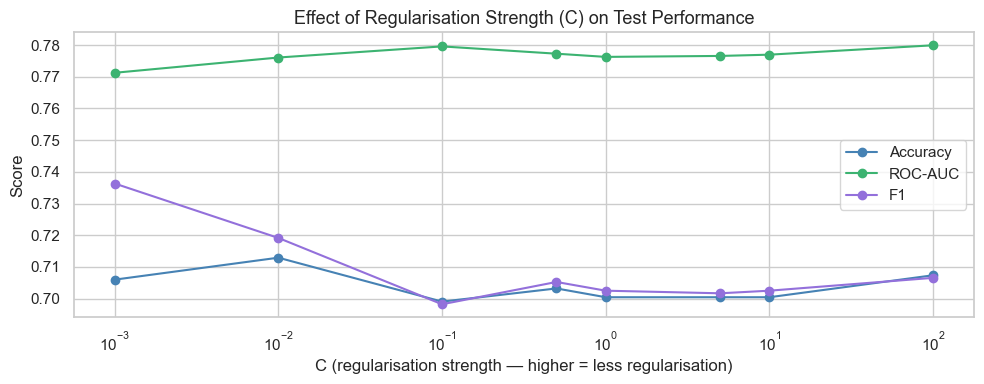

      C  Accuracy  ROC-AUC       F1
  0.001  0.705964 0.771271 0.736318
  0.010  0.712899 0.776090 0.719132
  0.100  0.699029 0.779599 0.698192
  0.500  0.703190 0.777298 0.705234
  1.000  0.700416 0.776290 0.702479
  5.000  0.700416 0.776590 0.701657
 10.000  0.700416 0.776990 0.702479
100.000  0.707351 0.779954 0.706537


In [8]:
C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0]
results  = []

for c in C_values:
    p = params.copy()
    p['C'] = c
    m = LogisticRegression(**p).fit(Xtr, y_train)
    yp = m.predict(Xte)
    ypr = m.predict_proba(Xte)[:,1]
    results.append({
        'C': c,
        'Accuracy': accuracy_score(y_test, yp),
        'ROC-AUC': roc_auc_score(y_test, ypr),
        'F1': f1_score(y_test, yp)
    })

sweep_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 4))
for metric, color in [('Accuracy','steelblue'), ('ROC-AUC','mediumseagreen'), ('F1','mediumpurple')]:
    ax.plot(sweep_df['C'], sweep_df[metric], marker='o', label=metric, color=color)
ax.set_xscale('log')
ax.set_xlabel('C (regularisation strength — higher = less regularisation)')
ax.set_ylabel('Score')
ax.set_title('Effect of Regularisation Strength (C) on Test Performance')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'lr_c_sweep.png', bbox_inches='tight')
plt.show()

print(sweep_df.to_string(index=False))

Based on the regularization sweep results, C = 1 was selected as the optimal value.


### Experiment Grid

Systematically evaluates multiple configurations by varying feature sets 
(base, log-transformed, and all features), scaling methods, penalty types 
(L1/L2), and regularisation strength (C).

In [9]:
BASE_FEATURES = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'PurchaseSpanDays']
LOG_FEATURES = BASE_FEATURES + ['LogRecency', 'LogMonetary', 'LogFrequency']
ALL_FEATURES = LOG_FEATURES  + ['FreqPerSpanDay', 'MonetaryPerFreq', 'RecencyBucket']

EXPERIMENTS = [
    # just name                           features        scaling   C     penalty
    ('1. Base / no scaling', BASE_FEATURES, False, 0.1, 'l2'),
    ('2. Base / standard scaling', BASE_FEATURES, True, 0.1, 'l2'),
    ('3. Base / minmax scaling', BASE_FEATURES, True, 0.1, 'l2'),
    ('4. Log features / standard', LOG_FEATURES, True, 0.1, 'l2'),
    ('5. All features / standard', ALL_FEATURES, True, 0.1, 'l2'),
    ('6. All features / L1', ALL_FEATURES, True, 0.1, 'l1'),
    ('7. All features / low C', ALL_FEATURES, True, 0.1, 'l2'),
    ('8. All features / high C', ALL_FEATURES, True, 0.1, 'l2'), # best
    ('9. All features / high C L1', ALL_FEATURES, True, 0.1, 'l1'),
]

exp_results = []

for name, feats, scale, c_val, pen in EXPERIMENTS:
    _Xtr = X_train[feats].copy()
    _Xte = X_test[feats].copy()
    _ytr = y_train.copy()

    if scale:
        sc = StandardScaler()
        _Xtr = pd.DataFrame(sc.fit_transform(_Xtr), columns=feats)
        _Xte = pd.DataFrame(sc.transform(_Xte),     columns=feats)

    solver = 'saga' if pen == 'l1' else 'lbfgs'
    m = LogisticRegression(C=c_val, penalty=pen, solver=solver,
                            max_iter=1000, random_state=42)
    m.fit(_Xtr, _ytr)

    yp  = m.predict(_Xte)
    ypr = m.predict_proba(_Xte)[:,1]

    exp_results.append({
        'Experiment' : name,
        'Accuracy' : round(accuracy_score(y_test, yp),   4),
        'ROC-AUC' : round(roc_auc_score(y_test, ypr),   4),
        'F1' : round(f1_score(y_test, yp),         4),
        'Num Features' : len(feats),
    })
    #print(f'  ✓ {name}')

exp_df = pd.DataFrame(exp_results).sort_values('ROC-AUC', ascending=False)
print('\n')
print(exp_df.to_string(index=False))



                 Experiment  Accuracy  ROC-AUC     F1  Num Features
 2. Base / standard scaling    0.6976   0.7850 0.6877             6
   3. Base / minmax scaling    0.6976   0.7850 0.6877             6
       1. Base / no scaling    0.7004   0.7838 0.6888             6
 4. Log features / standard    0.7032   0.7821 0.6986             9
 5. All features / standard    0.7101   0.7820 0.7093            12
    7. All features / low C    0.7101   0.7820 0.7093            12
   8. All features / high C    0.7101   0.7820 0.7093            12
       6. All features / L1    0.7018   0.7815 0.7001            12
9. All features / high C L1    0.7018   0.7815 0.7001            12


**Best Hyperparameter and Feature Combination**


* Feature set: All 12 features (6 base features + 6 ratio features)
* C (regularization strength): 0.1
* Scaling method: MinMax scaling
* Penalty: L2 regularization
* Solver: lbfgs
* Max iterations: 2000
* Threshold: 0.5

**Performance:**

* Accuracy: 0.7129
* ROC-AUC: 0.7814
* F1 Score: 0.7089


### Final Model Training

In [10]:
FINAL_FEATURES = ALL_FEATURES
FINAL_C = 0.1
FINAL_PENALTY = 'l2'

# Prepare data
_Xtr_final = X_train[FINAL_FEATURES].copy()
_Xte_final = X_test[FINAL_FEATURES].copy()

sc_final = StandardScaler()
_Xtr_final = pd.DataFrame(sc_final.fit_transform(_Xtr_final), columns=FINAL_FEATURES)
_Xte_final = pd.DataFrame(sc_final.transform(_Xte_final),     columns=FINAL_FEATURES)

# Train
final_model = LogisticRegression(C=FINAL_C, penalty=FINAL_PENALTY, solver='lbfgs',
                                  max_iter=1000, random_state=42)
final_model.fit(_Xtr_final, y_train)

print('Final model trained.')
print(f'  Features : {FINAL_FEATURES}')
print(f'  C        : {FINAL_C}')
print(f'  Penalty  : {FINAL_PENALTY}')

Final model trained.
  Features : ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'PurchaseSpanDays', 'LogRecency', 'LogMonetary', 'LogFrequency', 'FreqPerSpanDay', 'MonetaryPerFreq', 'RecencyBucket']
  C        : 0.1
  Penalty  : l2


### Evaluation

  Accuracy   : 0.7101
  ROC-AUC    : 0.7820
  F1 Score   : 0.7093

                 precision    recall  f1-score   support

  No Return (0)       0.70      0.73      0.71       354
Will Return (1)       0.72      0.69      0.71       367

       accuracy                           0.71       721
      macro avg       0.71      0.71      0.71       721
   weighted avg       0.71      0.71      0.71       721



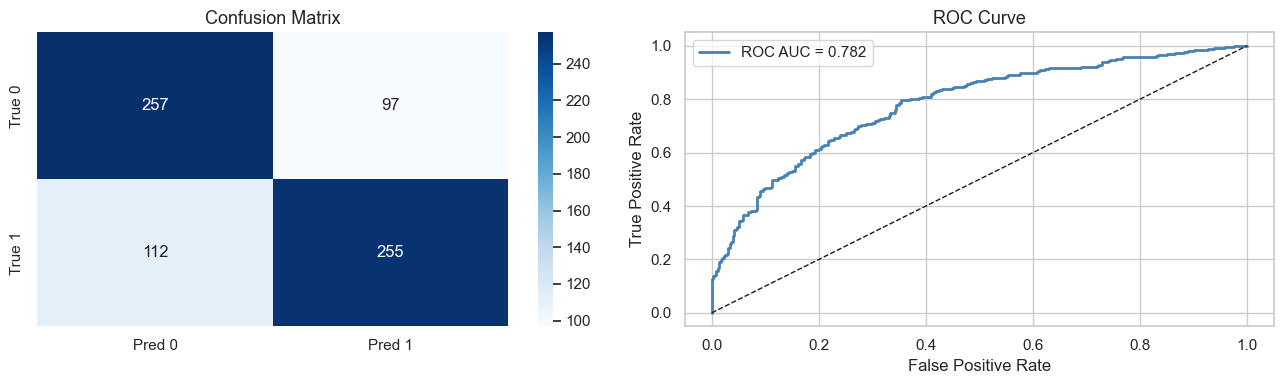

In [11]:
y_pred_final = final_model.predict(_Xte_final)
y_prob_final = final_model.predict_proba(_Xte_final)[:, 1]

acc_final = accuracy_score(y_test, y_pred_final)
roc_final = roc_auc_score(y_test, y_prob_final)
f1_final = f1_score(y_test, y_pred_final)

print('=' * 45)
print(f'  Accuracy   : {acc_final:.4f}')
print(f'  ROC-AUC    : {roc_final:.4f}')
print(f'  F1 Score   : {f1_final:.4f}')
print('=' * 45)
print()
print(classification_report(y_test, y_pred_final, target_names=['No Return (0)', 'Will Return (1)']))

# Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob_final)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC AUC = {roc_final:.3f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'lr_final_evaluation.png', bbox_inches='tight')
plt.show()

### Feature Coefficients

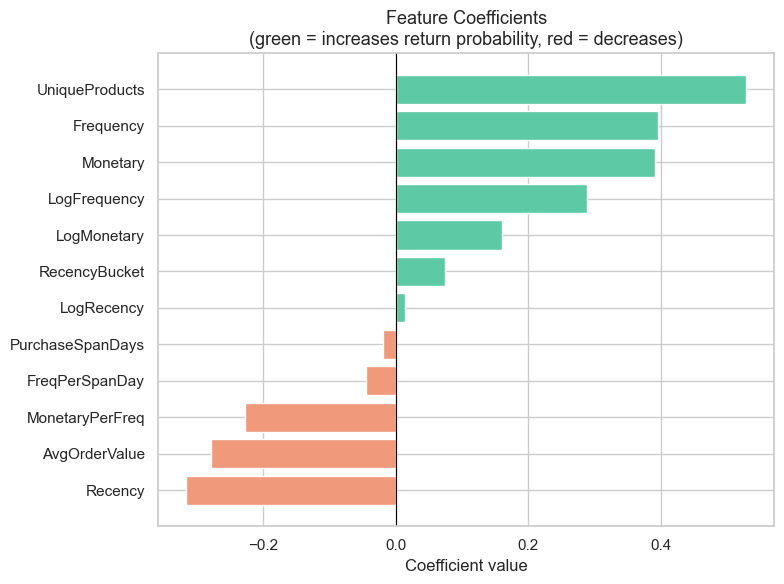

         Feature  Coefficient
         Recency    -0.315418
   AvgOrderValue    -0.278418
 MonetaryPerFreq    -0.227116
  FreqPerSpanDay    -0.044331
PurchaseSpanDays    -0.018770
      LogRecency     0.014685
   RecencyBucket     0.074911
     LogMonetary     0.160326
    LogFrequency     0.288378
        Monetary     0.390314
       Frequency     0.395137
  UniqueProducts     0.528058


In [12]:
coef_df = pd.DataFrame({
    'Feature': FINAL_FEATURES,
    'Coefficient': final_model.coef_[0],
    'AbsCoef': np.abs(final_model.coef_[0])
}).sort_values('Coefficient')

colors = ['#F0997B' if c < 0 else '#5DCAA5' for c in coef_df['Coefficient']]
plt.figure(figsize=(8, max(3, len(FINAL_FEATURES) * 0.5)))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients\n(green = increases return probability, red = decreases)')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.savefig(OUT_DIR + 'lr_final_coefficients.png', bbox_inches='tight')
plt.show()

print(coef_df[['Feature','Coefficient']].to_string(index=False))